# Semiconductor Data Analysis

This notebook loads the adjusted-close dataset from `semiconductor_close_analysis.csv.csv` and performs a first round of exploratory analysis for a semiconductor pairs trading project.

In [11]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

In [12]:
#prices = pd.read_csv("semiconductor_close_analysis.csv", index_col="date", parse_dates=True).sort_index()
prices = pd.read_csv("semiconductor_close_trade.csv", index_col="date", parse_dates=True).sort_index()
categories = pd.read_csv("categories.csv", index_col="ticker")
#categories_tickers = pd.read_csv("categories.csv", index_col="ticker")


df = categories.groupby("category").size().to_frame("count")
all_categories = df.index
core_categories = df.loc[df["count"] > 3].index

prices.index.name = "date"

#display(prices.head())
#display(categories)

## Normalized price paths per category

Normalizing each series to 1.0 makes it easier to compare relative movement across semiconductor names.

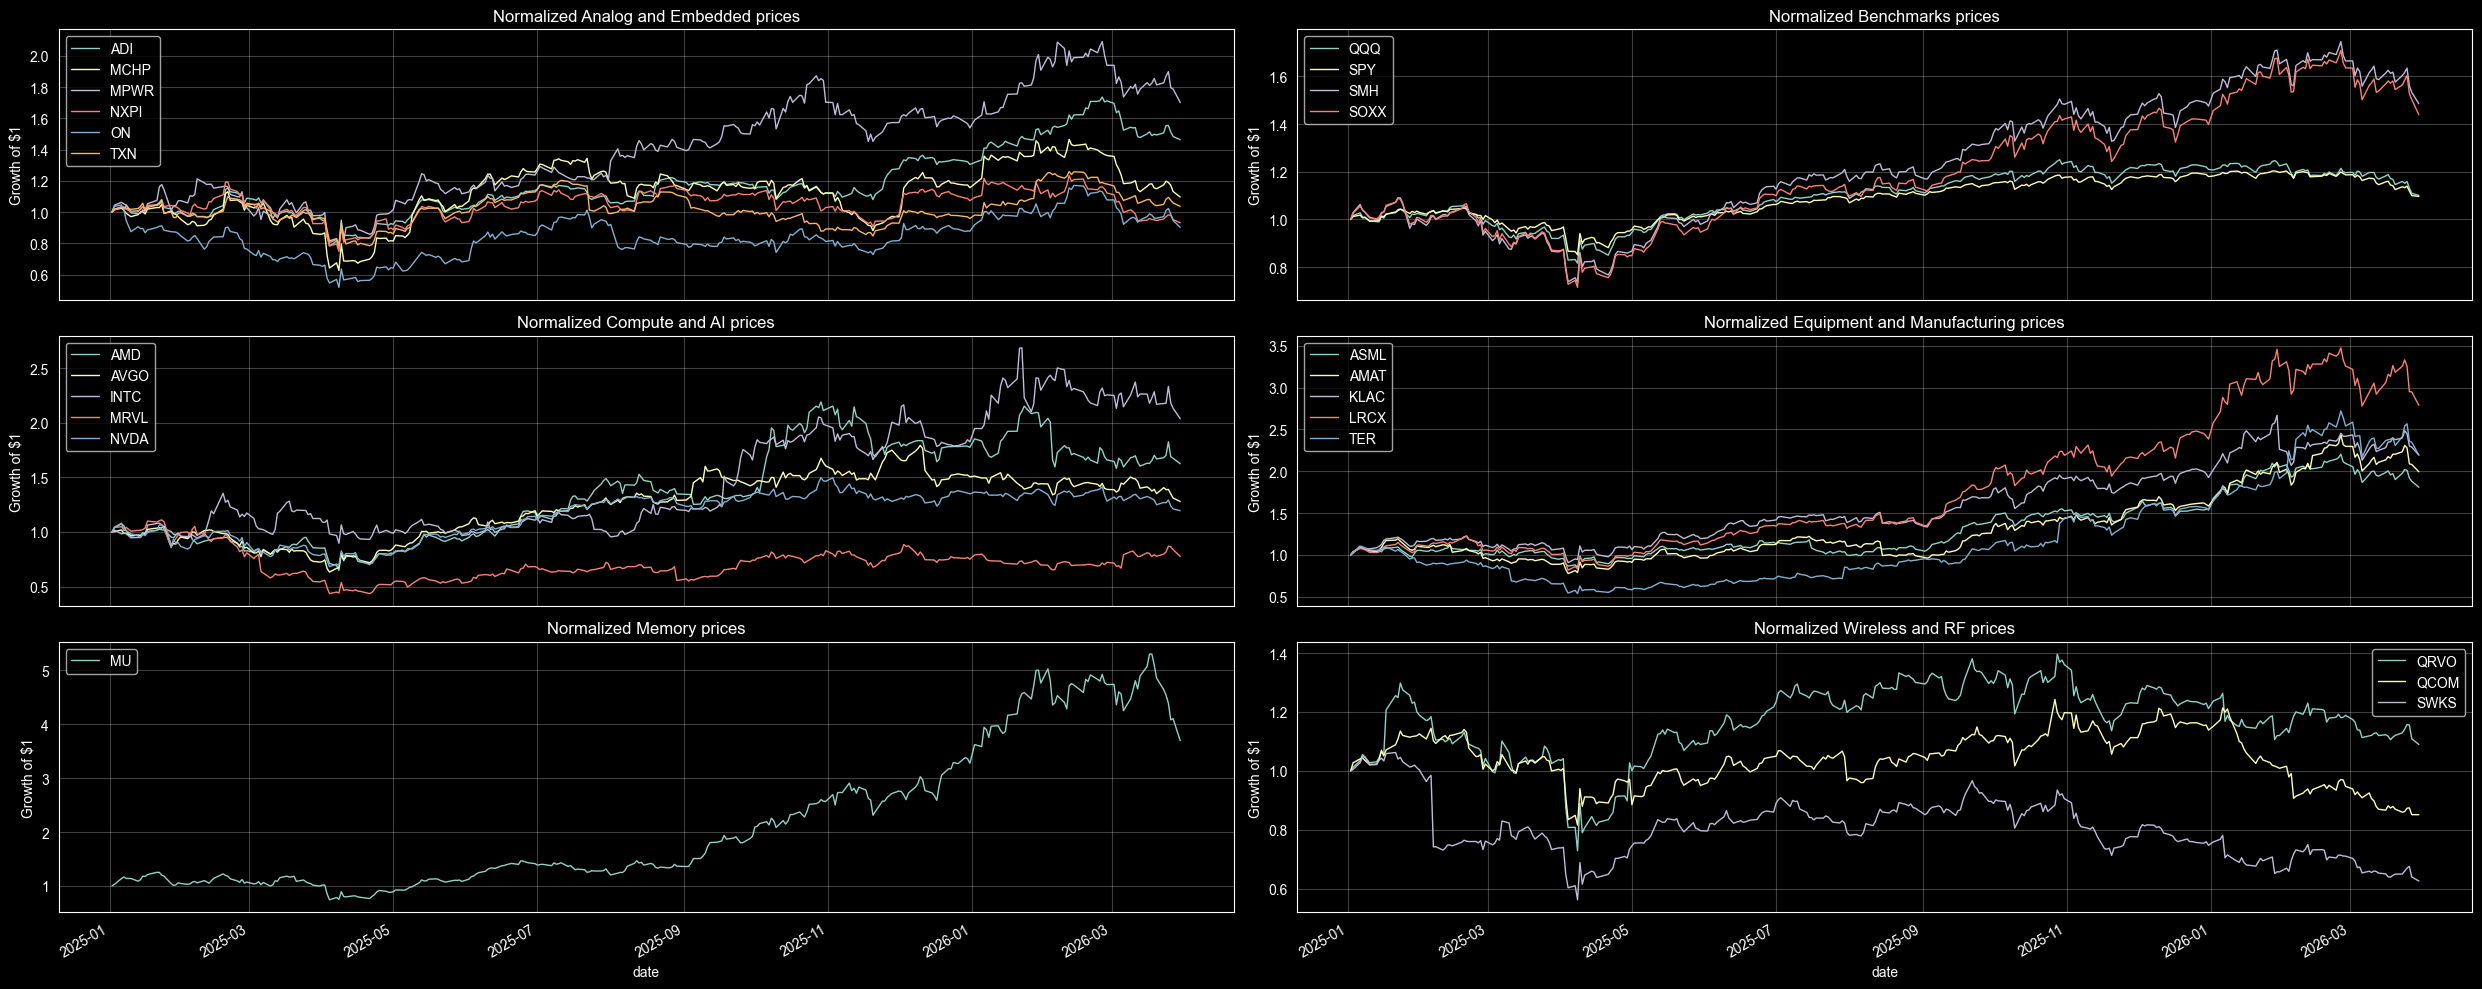

In [13]:
#print(all_categories)
n=len(all_categories)
m=int((n+1)/2)

fig, axes = plt.subplots(m, 2, figsize=(25, 10), sharex=True)
i,j=0,0
for ind in all_categories:
    plot_names=categories.loc[categories["category"] == ind].index

    normalized = prices[plot_names] / prices[plot_names].iloc[0]
    #display(plot_names,i,j)
    #display(normalized)
    #fig, ax = plt.subplots(figsize=(10, 5))
    normalized.plot(ax=axes[i,j], linewidth=1)
    axes[i,j].set_title("Normalized " + ind + ' prices')
    axes[i,j].set_ylabel("Growth of $1")
    axes[i,j].grid(alpha=0.25)
    plt.tight_layout()


    if j==0:
        j=1
    else:
        j=0
        i+=1
plt.show()



## Daily returns and correlation structure

In [14]:


returns = prices.pct_change().dropna(how="all")
return_summary = pd.DataFrame(
    {
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "annualized_volatility": returns.std() * np.sqrt(252),
        "category": categories.category,
    }
).sort_values(["category",'mean_daily_return'], ascending=False)

display(return_summary.round(4))

,mean_daily_return,daily_volatility,annualized_volatility,category
QRVO,0.0007,0.0297,0.4715,Wireless and RF
QCOM,-0.0002,0.0234,0.3713,Wireless and RF
SWKS,-0.0010,0.0306,0.4860,Wireless and RF
MU,0.0051,0.0409,0.6488,Memory
LRCX,0.0039,0.0327,0.5184,Equipment and Manufacturing
TER,0.0033,0.0385,0.6105,Equipment and Manufacturing
KLAC,0.0030,0.0297,0.4707,Equipment and Manufacturing
AMAT,0.0027,0.0300,0.4766,Equipment and Manufacturing
ASML,0.0023,0.0261,0.4142,Equipment and Manufacturing
INTC,0.0032,0.0421,0.6682,Compute and AI


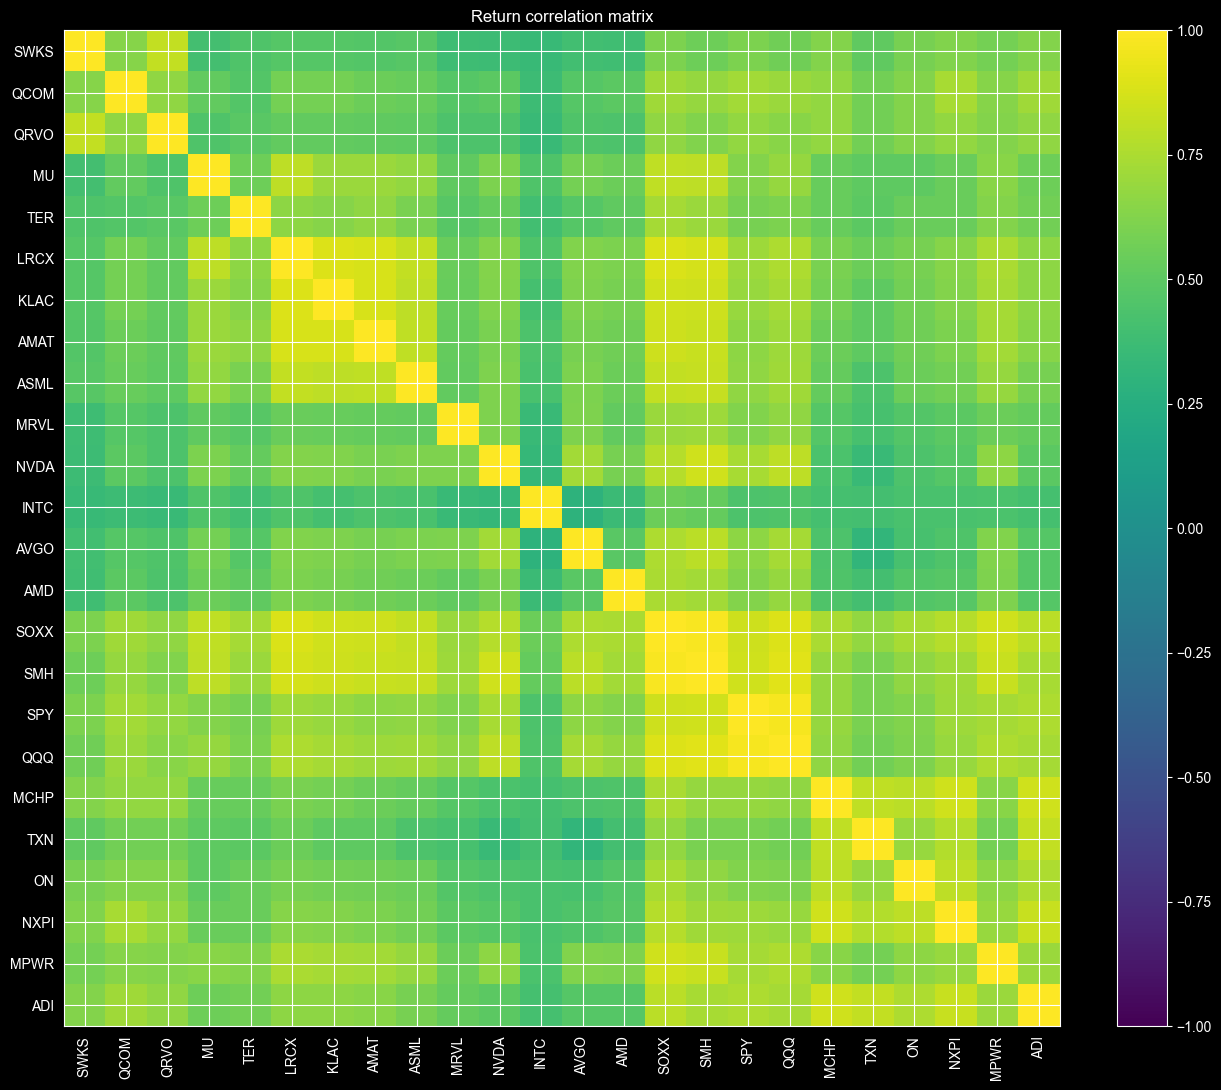

In [15]:
#display(categories.sort_values(["category"], ascending=False).index)


semiconductor_names =categories.sort_values(["category"], ascending=False).index#[ticker for ticker in prices.columns if ticker not in ["SMH", "SOXX", "QQQ", "SPY"]]
correlation_matrix = returns[semiconductor_names].corr()
#display(correlation_matrix)

fig, ax = plt.subplots(figsize=(15, 11))
image = ax.imshow(correlation_matrix, cmap="viridis", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Return correlation matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Most correlated semiconductor pairs

This is a simple first screen for candidate pairs before testing stationarity or spread behavior.

In [16]:
pair_rows = []
for left, right in itertools.combinations(semiconductor_names, 2):
    if categories.loc[left, "category"]!='Benchmarks' and categories.loc[right, "category"] !='Benchmarks':
        pair_rows.append(
            {
            "left": left,
            "right": right,
            "correlation": returns[left].corr(returns[right]),
            "category_left": categories.loc[left, "category"]  ,
            "category_right": categories.loc[right, "category"] ,
            }
        )

top_pairs = pd.DataFrame(pair_rows).sort_values("correlation", ascending=False).reset_index(drop=True)
top_compute_ai = top_pairs.loc[(top_pairs.category_left=='Compute and AI')|( top_pairs.category_right=='Compute and AI')]
display(top_pairs.head(10))
display(top_compute_ai.head(10))

,left,right,correlation,category_left,category_right
0,LRCX,KLAC,0.891729,Equipment and Manufacturing,Equipment and Manufacturing
1,LRCX,AMAT,0.879708,Equipment and Manufacturing,Equipment and Manufacturing
2,KLAC,AMAT,0.877340,Equipment and Manufacturing,Equipment and Manufacturing
3,MCHP,NXPI,0.854319,Analog and Embedded,Analog and Embedded
4,MCHP,ADI,0.853102,Analog and Embedded,Analog and Embedded
5,NXPI,ADI,0.835889,Analog and Embedded,Analog and Embedded
6,LRCX,ASML,0.817387,Equipment and Manufacturing,Equipment and Manufacturing
7,TXN,ADI,0.816750,Analog and Embedded,Analog and Embedded
8,SWKS,QRVO,0.813803,Wireless and RF,Wireless and RF
9,MCHP,TXN,0.809353,Analog and Embedded,Analog and Embedded


,left,right,correlation,category_left,category_right
20,NVDA,AVGO,0.724815,Compute and AI,Compute and AI
37,NVDA,MPWR,0.661298,Compute and AI,Analog and Embedded
52,LRCX,NVDA,0.630327,Equipment and Manufacturing,Compute and AI
56,KLAC,NVDA,0.621591,Equipment and Manufacturing,Compute and AI
57,LRCX,AVGO,0.619408,Equipment and Manufacturing,Compute and AI
59,AVGO,MPWR,0.618749,Compute and AI,Analog and Embedded
60,MRVL,NVDA,0.616587,Compute and AI,Compute and AI
61,KLAC,AVGO,0.615433,Equipment and Manufacturing,Compute and AI
62,MRVL,AVGO,0.614453,Compute and AI,Compute and AI
63,AMD,MPWR,0.613476,Compute and AI,Analog and Embedded


## Simple spread diagnostic for the top pair

This is not a full cointegration test, but it is a useful first look at whether the pair moves together and whether the spread looks mean-reverting.

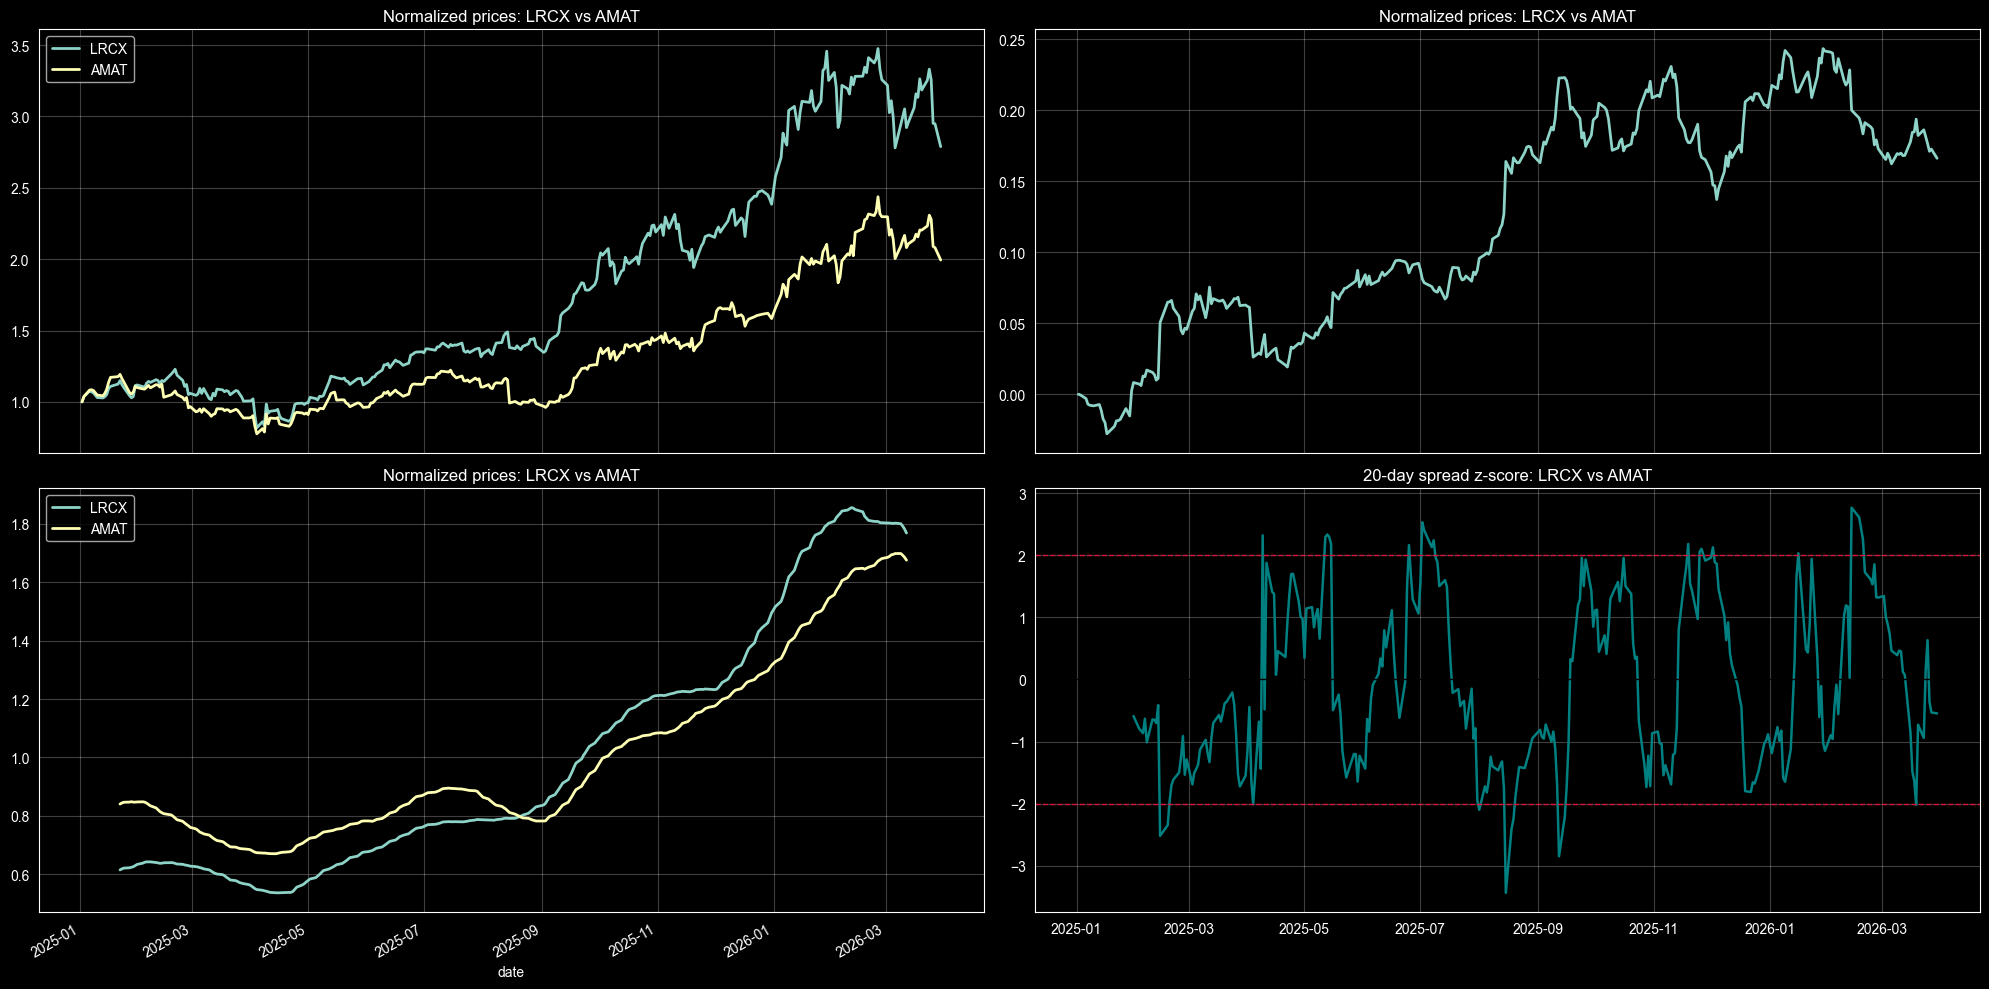

Top pair by return correlation: LRCX-AMAT
Correlation: 0.8917


In [18]:
top_pair = top_pairs.iloc[0]
left_name = 'LRCX' #top_pair["left"]
right_name = 'AMAT' # top_pair["right"]

#name1='LRCX'
#name2='AMAT'

pair_prices = prices[[left_name, right_name]].dropna().copy()
norm_pair = pair_prices / pair_prices.iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)

(pair_prices / pair_prices.iloc[0]).plot(ax=axes[0,0], linewidth=2)
axes[0,0].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[0,0].grid(alpha=0.25)

((norm_pair.loc[:,left_name]-norm_pair.loc[:,right_name])/(norm_pair.loc[:,left_name]+norm_pair.loc[:,right_name])).plot(ax=axes[0,1], linewidth=2)
axes[0,1].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[0,1].grid(alpha=0.25)

trend =  pair_prices.rolling(window=25, center=True).mean().dropna()
trend2 =  pair_prices.rolling(window=100, center=True).mean().dropna()
#display(pair_prices.loc[:,left_name])
#display(pair_prices.loc[:,left_name].rolling(window=50, center=True).mean().dropna())
#display(trend)

(trend / trend.mean()).plot(ax=axes[1,0], linewidth=2)
axes[1,0].set_title(f"Normalized prices: {left_name} vs {right_name}")
axes[1,0].grid(alpha=0.25)

#(trend2 / trend2.iloc[0]).plot(ax=axes[2], linewidth=2)




beta = np.polyfit(pair_prices[left_name], pair_prices[right_name], 1)[0]
spread = pair_prices[right_name] - beta * pair_prices[left_name]
zscore = (spread - spread.rolling(20).mean()) / spread.rolling(20).std()


axes[1,1].plot(spread.index, zscore, color="teal", linewidth=1.8)
axes[1,1].axhline(0, color="black", linewidth=1)
axes[1,1].axhline(2, color="crimson", linestyle="--", linewidth=1)
axes[1,1].axhline(-2, color="crimson", linestyle="--", linewidth=1)
axes[1,1].set_title(f"20-day spread z-score: {left_name} vs {right_name}")
axes[1,1].grid(alpha=0.25)


plt.tight_layout()
plt.show()

print(f"Top pair by return correlation: {left_name}-{right_name}")
print(f"Correlation: {top_pair['correlation']:.4f}")
#print(f"Hedge ratio estimate: {beta:.4f}")

# Cointegration test